# URL Structure — hhs.gov

Analyses SURT-derived URL structure for `hhs.gov` captures across all crawl years.

All queries use the materialised `surthost_seg_*` and `surtpath_*` columns populated by `add_surtkey_columns.py`. No regex on the raw URL; everything is derived from the SURT key.

In [1]:
import sys
sys.path.insert(0, '..')

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

from domain_analysis import (
    base_domain_sql,
    subdomain_sql,
    build_domain_summary,
    build_subdomain_breakdown,
)

pd.set_option('display.max_rows', 120)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

hhs_con = duckdb.connect('../data/domains/08_hhs/cdxj.duckdb', read_only=True)
print('Connected.')
hhs_con.sql("SELECT COUNT(*) AS total_rows FROM eot_captures").show()

Connected.
┌────────────┐
│ total_rows │
│   int64    │
├────────────┤
│   18878987 │
└────────────┘



In [2]:
# Total captures per crawl year
hhs_con.sql("""
    SELECT crawl_year, COUNT(*) AS captures
    FROM eot_captures
    GROUP BY 1 ORDER BY 1
""").show()

┌────────────┬──────────┐
│ crawl_year │ captures │
│  varchar   │  int64   │
├────────────┼──────────┤
│ 2004       │   619149 │
│ 2008       │  2361866 │
│ 2012       │   366023 │
│ 2016       │   515863 │
│ 2020       │  7338834 │
│ 2024       │  7677252 │
└────────────┴──────────┘



In [3]:
# Top hosts by year (raw host column)
hhs_con.sql("""
    SELECT host, crawl_year, COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2
    ORDER BY n DESC
""").show(max_rows=50)

┌─────────────────────────────────────┬────────────┬─────────┐
│                host                 │ crawl_year │    n    │
│               varchar               │  varchar   │  int64  │
├─────────────────────────────────────┼────────────┼─────────┤
│ peerta.acf.hhs.gov                  │ 2020       │ 4909182 │
│ eclkc.ohs.acf.hhs.gov               │ 2024       │ 3052335 │
│ peerta.acf.hhs.gov                  │ 2024       │ 2292131 │
│ childcareta.acf.hhs.gov             │ 2020       │ 1578800 │
│ www.hhs.gov                         │ 2024       │  351470 │
│ earlyeducatorcentral.acf.hhs.gov    │ 2024       │  272606 │
│ www.hhs.gov                         │ 2008       │  249148 │
│ www.cms.hhs.gov                     │ 2008       │  233764 │
│ contractorsupport.acf.hhs.gov       │ 2008       │  188841 │
│ faq.acf.hhs.gov                     │ 2008       │  184212 │
│ ccdf.acf.hhs.gov                    │ 2008       │  182606 │
│ regulations.acf.hhs.gov             │ 2008       │  1

### SURT host columns

The DB carries `surthost`, `surthost_seg_0..5`, and `surtpath_1..5` as physical columns parsed from the SURT key by `add_surtkey_columns.py`.

SURT canonicalization strips a leading `www`, so `www.{domain}` rows have the same `surthost` as bare `{domain}` and their `surthost_seg_2` is NULL.

In [4]:
# Verify SURT columns on a sample
hhs_con.sql("""
    SELECT host, surthost,
           surthost_seg_0 AS tld,
           surthost_seg_1 AS reg_dom,
           surthost_seg_2 AS sub1,
           surthost_seg_3 AS sub2,
           surtpath_1, surtpath_2
    FROM eot_captures
    LIMIT 8
""").show()

┌─────────────┬──────────┬─────────┬─────────┬─────────┬─────────┬──────────────┬───────────────────────┐
│    host     │ surthost │   tld   │ reg_dom │  sub1   │  sub2   │  surtpath_1  │      surtpath_2       │
│   varchar   │ varchar  │ varchar │ varchar │ varchar │ varchar │   varchar    │        varchar        │
├─────────────┼──────────┼─────────┼─────────┼─────────┼─────────┼──────────────┼───────────────────────┤
│ www.hhs.gov │ gov,hhs  │ gov     │ hhs     │ NULL    │ NULL    │ images       │ aging.jpg             │
│ hhs.gov     │ gov,hhs  │ gov     │ hhs     │ NULL    │ NULL    │ images       │ eaglefoot2.jpg        │
│ www.hhs.gov │ gov,hhs  │ gov     │ hhs     │ NULL    │ NULL    │ images       │ resourcelocators.jpg  │
│ hhs.gov     │ gov,hhs  │ gov     │ hhs     │ NULL    │ NULL    │ images       │ safetyandwellness.jpg │
│ www.hhs.gov │ gov,hhs  │ gov     │ hhs     │ NULL    │ NULL    │ images       │ search.jpg            │
│ hhs.gov     │ gov,hhs  │ gov     │ hhs     │

### DomainDataSummary — high-level domain structure (SURT-derived)

In [5]:
domain_summary = build_domain_summary(hhs_con)
domain_summary

,base_domain,total_captures,unique_subdomains,years_covered,top_subdomain,top_subdomain_count,bare_captures,pct_bare
0,hhs.gov,18795878,272,6,acf,14971703,895465.0,4.8


In [6]:
# Subdomain breakdown (surthost_seg_2) by year
subdomain_df = hhs_con.sql("""
    SELECT
        COALESCE(surthost_seg_2, '(bare/www)') AS subdomain,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    WHERE surtkey IS NOT NULL
    GROUP BY 1, 2
""").df()

subdomain_pivot = (subdomain_df
    .pivot_table(index='subdomain', columns='crawl_year', values='n', aggfunc='sum')
    .fillna(0).astype(int))
subdomain_pivot['total'] = subdomain_pivot.sum(axis=1)
subdomain_pivot = subdomain_pivot.sort_values('total', ascending=False).head(30)

total_subs = hhs_con.sql("""
    SELECT COUNT(DISTINCT COALESCE(surthost_seg_2, '(bare/www)'))
    FROM eot_captures WHERE surtkey IS NOT NULL
""").fetchone()[0]
print(f"Unique top-level subdomain labels (surthost_seg_2): {total_subs:,}")
subdomain_pivot

Unique top-level subdomain labels (surthost_seg_2): 272


crawl_year,2004,2008,2012,2016,2020,2024,total
subdomain,,,,,,,
acf,238270,1778254,77384,164766,6740277,5972752,14971703
(bare/www),36959,249602,63798,78573,117855,431787,978574
cms,152466,234518,7312,73143,22806,27597,517842
aspe,56318,41892,26326,29266,115973,90340,360115
digitalmedia,0,0,0,12595,74839,206146,293580
oig,11579,38163,1077,37433,38768,120463,247483
iacc,0,260,629,8375,43861,147972,201097
taggs,648,27,6785,10872,13091,102146,133569
asprtracie,0,0,0,8048,22284,82509,112841


### SURT path segment analysis

In [7]:
# SURT path position 1
seg1 = hhs_con.sql("""
    SELECT
        COALESCE(NULLIF(surtpath_1, ''), '(root)') AS seg1,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2
""").df()

seg1_pivot = seg1.pivot_table(index='seg1', columns='crawl_year', values='n',
                        aggfunc='sum').fillna(0).astype(int)
seg1_pivot['total'] = seg1_pivot.sum(axis=1)
seg1_pivot = seg1_pivot.sort_values('total', ascending=False)
seg1_pivot.head(30)

crawl_year,2004,2008,2012,2016,2020,2024,total
seg1,,,,,,,
archive,0,1,0,0,4576254,5437,4581692
search,22159,376,7084,6379,314641,2328965,2679604
browse,0,0,231,4384,44718,2023914,2073247
cgi-bin,211325,1445493,33,4,1,5,1656861
global-sitewide-search,0,0,0,0,1494767,0,1494767
es,0,0,0,65,20906,962965,983936
sites,32,0,15620,82516,96452,293365,487985
coursework,0,0,0,8341,18597,267311,294249
(root),97,415,494,5669,41161,174465,222301


In [8]:
# SURT path position 2
seg2 = hhs_con.sql("""
    SELECT
        COALESCE(NULLIF(surtpath_1, ''), '(none)') AS seg1,
        COALESCE(NULLIF(surtpath_2, ''), '(none)') AS seg2,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2, 3
""").df()

seg2_pivot = seg2.pivot_table(index=['seg1', 'seg2'], columns='crawl_year', values='n',
                        aggfunc='sum').fillna(0).astype(int)
seg2_pivot['total'] = seg2_pivot.sum(axis=1)
seg2_pivot = seg2_pivot.sort_values('total', ascending=False)
seg2_pivot.head(30)

,crawl_year,2004,2008,2012,2016,2020,2024,total
seg1,seg2,,,,,,,
archive,(none),0,0,0,0,4574949,177,4575126
search,content,0,0,0,9,314553,2328840,2643402
global-sitewide-search,(none),0,0,0,0,1494767,0,1494767
browse,national-centers,0,0,0,0,8766,1278498,1287264
es,browse,0,0,0,0,14119,924043,938162
sites,default,0,0,5050,64546,84697,292913,447206
browse,topic,0,0,0,0,14096,289932,304028
coursework,(none),0,0,0,8341,18597,267311,294249
(none),(none),99,416,494,5669,41161,174465,222304


In [9]:
# SURT path position 3
seg3 = hhs_con.sql("""
    SELECT
        COALESCE(NULLIF(surtpath_1, ''), '(none)') AS seg1,
        COALESCE(NULLIF(surtpath_2, ''), '(none)') AS seg2,
        COALESCE(NULLIF(surtpath_3, ''), '(none)') AS seg3,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2, 3, 4
""").df()

seg3_pivot = seg3.pivot_table(index=['seg1', 'seg2', 'seg3'], columns='crawl_year', values='n',
                        aggfunc='sum').fillna(0).astype(int)
seg3_pivot['total'] = seg3_pivot.sum(axis=1)
seg3_pivot = seg3_pivot.sort_values('total', ascending=False)
seg3_pivot.head(30)

,,crawl_year,2004,2008,2012,2016,2020,2024,total
seg1,seg2,seg3,,,,,,,
archive,(none),(none),0,0,0,0,4574949,177,4575126
search,content,(none),0,0,0,9,314553,1742296,2056858
global-sitewide-search,(none),(none),0,0,0,0,1494767,0,1494767
browse,national-centers,health-behavioral-health-safety,0,0,0,0,1547,1179496,1181043
search,content,grid,0,0,0,0,0,586544,586544
es,browse,topic,0,0,0,0,5258,505766,511024
sites,default,files,0,0,5050,64490,70892,292794,433226
es,browse,national-centers,0,0,0,0,3125,295746,298871
coursework,(none),(none),0,0,0,8341,18597,267311,294249


In [10]:
# SURT path position 4
seg4 = hhs_con.sql("""
    SELECT
        COALESCE(NULLIF(surtpath_1, ''), '(none)') AS seg1,
        COALESCE(NULLIF(surtpath_2, ''), '(none)') AS seg2,
        COALESCE(NULLIF(surtpath_3, ''), '(none)') AS seg3,
        COALESCE(NULLIF(surtpath_4, ''), '(none)') AS seg4,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2, 3, 4, 5
""").df()

seg4_pivot = seg4.pivot_table(index=['seg1', 'seg2', 'seg3', 'seg4'], columns='crawl_year', values='n',
                        aggfunc='sum').fillna(0).astype(int)
seg4_pivot['total'] = seg4_pivot.sum(axis=1)
seg4_pivot = seg4_pivot.sort_values('total', ascending=False)
seg4_pivot.head(30)

,,,crawl_year,2004,2008,2012,2016,2020,2024,total
seg1,seg2,seg3,seg4,,,,,,,
archive,(none),(none),(none),0,0,0,0,4574949,177,4575126
search,content,(none),(none),0,0,0,9,314553,1742296,2056858
global-sitewide-search,(none),(none),(none),0,0,0,0,1494767,0,1494767
browse,national-centers,health-behavioral-health-safety,(none),0,0,0,0,1547,1179496,1181043
search,content,grid,(none),0,0,0,0,0,586544,586544
es,browse,topic,physical-health,0,0,0,0,104,468543,468647
coursework,(none),(none),(none),0,0,0,8341,18597,267311,294249
es,browse,national-centers,health-behavioral-health-safety,0,0,0,0,793,244453,245246
(none),(none),(none),(none),99,416,494,5669,41161,174465,222304


In [11]:
# SURT path position 5
seg5 = hhs_con.sql("""
    SELECT
        COALESCE(NULLIF(surtpath_1, ''), '(none)') AS seg1,
        COALESCE(NULLIF(surtpath_2, ''), '(none)') AS seg2,
        COALESCE(NULLIF(surtpath_3, ''), '(none)') AS seg3,
        COALESCE(NULLIF(surtpath_4, ''), '(none)') AS seg4,
        COALESCE(NULLIF(surtpath_5, ''), '(none)') AS seg5,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2, 3, 4, 5, 6
""").df()

seg5_pivot = seg5.pivot_table(index=['seg1', 'seg2', 'seg3', 'seg4', 'seg5'], columns='crawl_year', values='n',
                        aggfunc='sum').fillna(0).astype(int)
seg5_pivot['total'] = seg5_pivot.sum(axis=1)
seg5_pivot = seg5_pivot.sort_values('total', ascending=False)
seg5_pivot.head(30)

,,,,crawl_year,2004,2008,2012,2016,2020,2024,total
seg1,seg2,seg3,seg4,seg5,,,,,,,
archive,(none),(none),(none),(none),0,0,0,0,4574949,177,4575126
search,content,(none),(none),(none),0,0,0,9,314553,1742296,2056858
global-sitewide-search,(none),(none),(none),(none),0,0,0,0,1494767,0,1494767
browse,national-centers,health-behavioral-health-safety,(none),(none),0,0,0,0,1547,1179496,1181043
search,content,grid,(none),(none),0,0,0,0,0,586544,586544
es,browse,topic,physical-health,(none),0,0,0,0,104,468543,468647
coursework,(none),(none),(none),(none),0,0,0,8341,18597,267311,294249
es,browse,national-centers,health-behavioral-health-safety,(none),0,0,0,0,793,244453,245246
(none),(none),(none),(none),(none),99,416,494,5669,41161,174465,222304


### File extensions — hhs.gov

In [12]:
ext_df = hhs_con.sql("""
    SELECT
        COALESCE(NULLIF(lower(regexp_extract(
            regexp_extract(surtkey, '\\)([^?]*)', 1),
            '\\.([a-zA-Z0-9]+)$', 1)), ''), '(none)') AS ext,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2
""").df()

ext_pivot = ext_df.pivot(index='ext', columns='crawl_year', values='n').fillna(0).astype(int)
ext_pivot['total'] = ext_pivot.sum(axis=1)
ext_pivot = ext_pivot.sort_values('total', ascending=False)
ext_pivot.head(30)

crawl_year,2004,2008,2012,2016,2020,2024,total
ext,,,,,,,
(none),10663,40802,102515,130635,6897814,6682854,13865283
php,210987,1445186,502,1762,1672,1930,1662039
pdf,41078,83124,24747,209065,71426,221340,650780
html,54183,179024,45624,9517,46410,163407,498165
asp,104475,201655,2180,3661,12606,30762,355339
htm,56071,111581,23274,11016,14995,17626,234563
cfm,64741,97430,16732,10197,18087,4471,211658
jpg,8012,22560,24830,17382,38565,95957,207306
png,31,31006,11979,20486,39739,85212,188453


### Filenames — hhs.gov

In [13]:
fname_df = hhs_con.sql("""
    SELECT
        COALESCE(NULLIF(regexp_extract(
            regexp_extract(surtkey, '\\)([^?]*)', 1),
            '/([^/]+)$', 1), ''), '(root)') AS filename,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2
""").df()

fname_pivot = fname_df.pivot(index='filename', columns='crawl_year', values='n').fillna(0).astype(int)
fname_pivot['total'] = fname_pivot.sum(axis=1)
fname_pivot = fname_pivot.sort_values('total', ascending=False)
fname_pivot.head(30)

crawl_year,2004,2008,2012,2016,2020,2024,total
filename,,,,,,,
archive,20,0,9,2,4574957,225,4575213
content,0,1,2,10,314567,1750596,2065176
global-sitewide-search,0,0,0,0,1494767,0,1494767
health-behavioral-health-safety,0,0,0,0,2340,1423949,1426289
grid,0,0,0,0,3,586550,586553
physical-health,0,0,0,3,581,495627,496211
coursework,0,0,0,8341,18597,267311,294249
prnt_adp.php,28986,235867,0,0,0,0,264853
email_adp.php,24016,231172,0,0,0,0,255188


## Visualizations

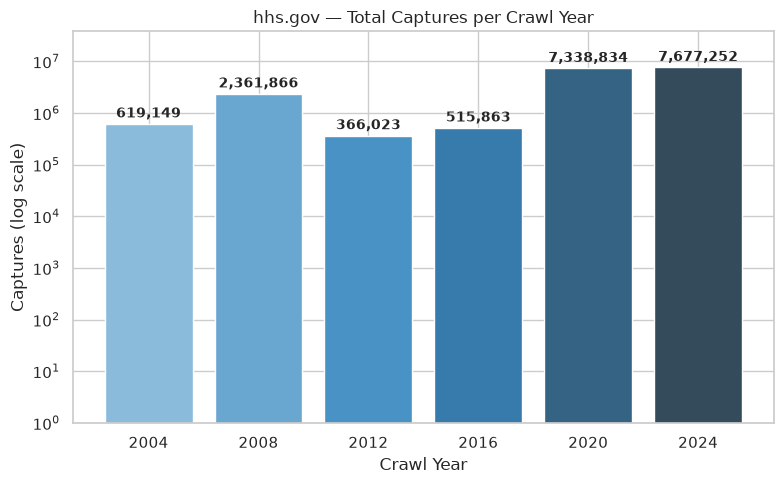

In [14]:
# Viz 1: Captures over time
year_counts = hhs_con.sql("""
    SELECT crawl_year, COUNT(*) AS captures
    FROM eot_captures GROUP BY 1 ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(year_counts['crawl_year'], year_counts['captures'],
              color=sns.color_palette('Blues_d', len(year_counts)))
ax.set_yscale('log')
ax.set_ylabel('Captures (log scale)')
ax.set_xlabel('Crawl Year')
ax.set_title('hhs.gov — Total Captures per Crawl Year')
for bar, val in zip(bars, year_counts['captures']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(1, year_counts['captures'].max() * 5)
plt.tight_layout()
plt.show()

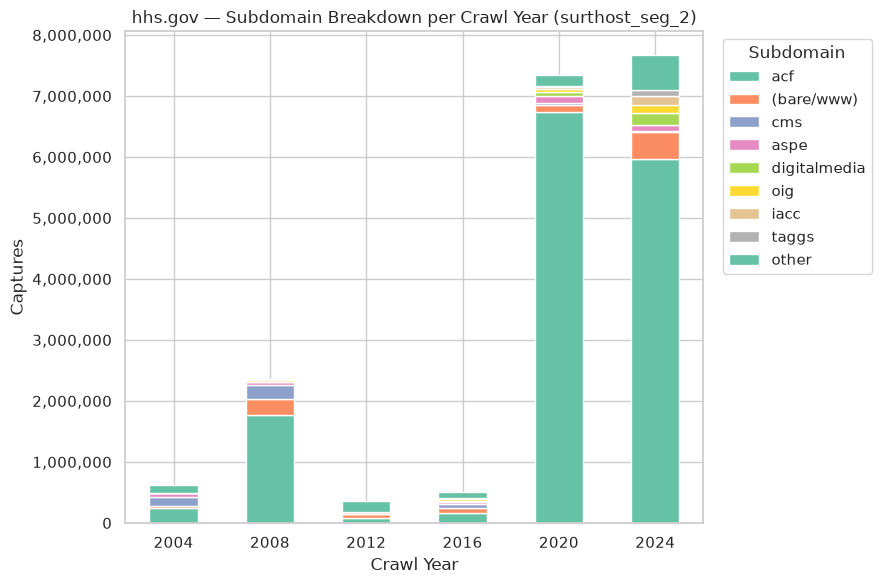

In [15]:
# Viz 2: Subdomain stacked bar
host_year = hhs_con.sql("""
    SELECT
        COALESCE(surthost_seg_2, '(bare/www)') AS subdomain,
        crawl_year, COUNT(*) AS n
    FROM eot_captures WHERE surtkey IS NOT NULL
    GROUP BY 1, 2
""").df()

totals = host_year.groupby('subdomain')['n'].sum().sort_values(ascending=False)
top_subs = totals.head(8).index.tolist()
host_year['subdomain'] = host_year['subdomain'].where(host_year['subdomain'].isin(top_subs), 'other')

host_pivot = (host_year.pivot_table(index='crawl_year', columns='subdomain', values='n', aggfunc='sum')
                       .fillna(0).astype(int))
col_order = [s for s in top_subs if s in host_pivot.columns]
if 'other' in host_pivot.columns:
    col_order.append('other')
host_pivot = host_pivot[col_order]

ax = host_pivot.plot(kind='bar', stacked=True, figsize=(9, 6),
                     color=sns.color_palette('Set2', len(col_order)))
ax.set_ylabel('Captures')
ax.set_xlabel('Crawl Year')
ax.set_title('hhs.gov — Subdomain Breakdown per Crawl Year (surthost_seg_2)')
ax.legend(title='Subdomain', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

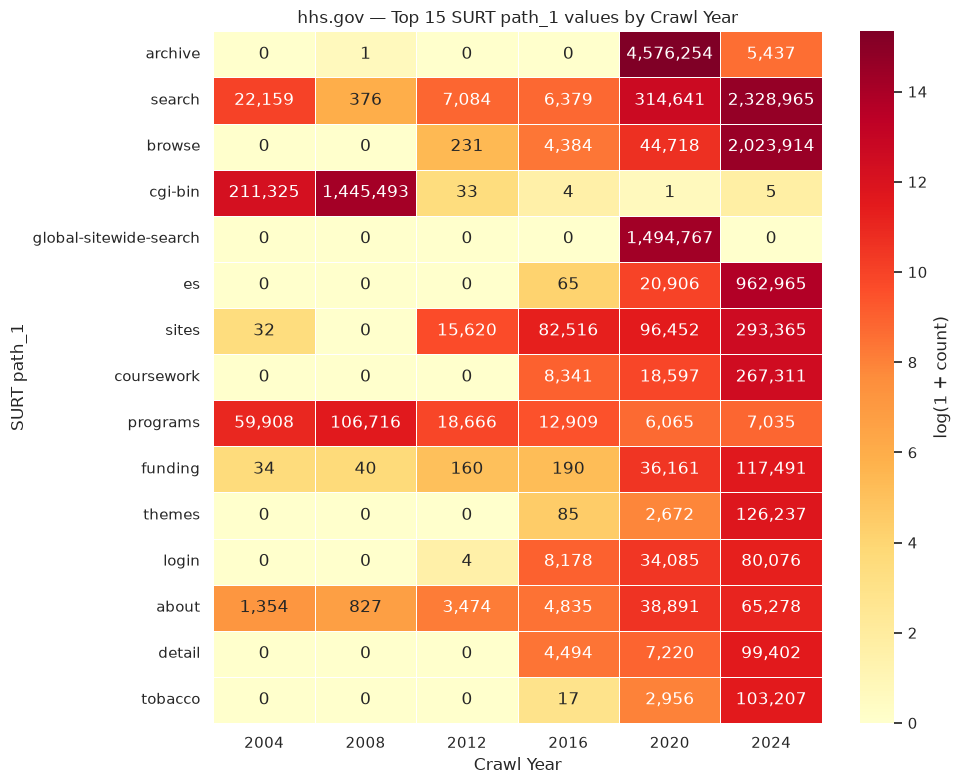

In [16]:
# Viz 3: Top 15 surtpath_1 values heatmap
top15 = seg1_pivot[seg1_pivot.index != '(root)'].head(15)
year_cols = [c for c in top15.columns if c != 'total']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(np.log1p(top15[year_cols]), annot=top15[year_cols].values,
            fmt=',d', cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'log(1 + count)'})
ax.set_title('hhs.gov — Top 15 SURT path_1 values by Crawl Year')
ax.set_ylabel('SURT path_1')
ax.set_xlabel('Crawl Year')
plt.tight_layout()
plt.show()

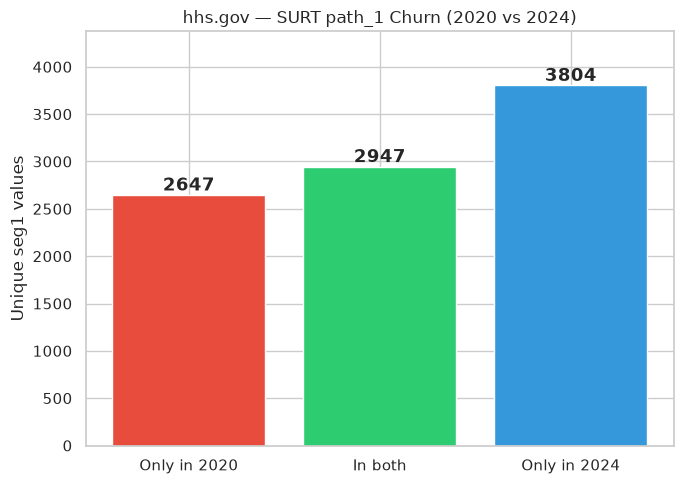

2020: 5594 unique seg1 | 2024: 6751 | 2647 dropped, 3804 new, 2947 persisted


In [17]:
# Viz 4: path_1 churn between the two most recent crawl years
year_cols_sorted = sorted([c for c in seg1_pivot.columns if c != 'total'])
if len(year_cols_sorted) >= 2:
    yr_a, yr_b = year_cols_sorted[-2], year_cols_sorted[-1]
    in_a = set(seg1_pivot[seg1_pivot[yr_a] > 0].index)
    in_b = set(seg1_pivot[seg1_pivot[yr_b] > 0].index)
    only_a = len(in_a - in_b)
    only_b = len(in_b - in_a)
    both   = len(in_a & in_b)

    churn = pd.DataFrame({
        'category': [f'Only in {yr_a}', 'In both', f'Only in {yr_b}'],
        'count': [only_a, both, only_b]
    })
    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(churn['category'], churn['count'], color=['#e74c3c', '#2ecc71', '#3498db'])
    for bar, val in zip(bars, churn['count']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
    ax.set_ylabel('Unique seg1 values')
    ax.set_title(f'hhs.gov — SURT path_1 Churn ({yr_a} vs {yr_b})')
    ax.set_ylim(0, max(churn['count']) * 1.15)
    plt.tight_layout()
    plt.show()
    print(f"{yr_a}: {len(in_a)} unique seg1 | {yr_b}: {len(in_b)} | "
          f"{only_a} dropped, {only_b} new, {both} persisted")
else:
    print("Only one crawl year available — churn chart skipped.")

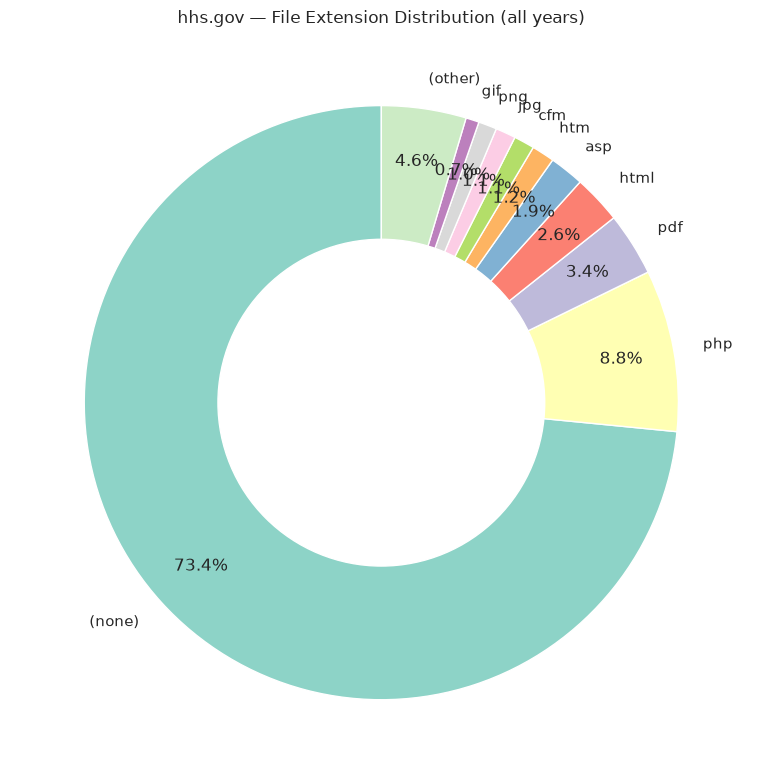

In [18]:
# Viz 5: Extension donut chart
top_ext = ext_pivot.head(10).copy()
other_total = ext_pivot.iloc[10:]['total'].sum()
import pandas as _pd
donut_data = _pd.concat([top_ext[['total']], _pd.DataFrame({'total': [other_total]}, index=['(other)'])])

fig, ax = plt.subplots(figsize=(8, 8))
colors = sns.color_palette('Set3', len(donut_data))
ax.pie(donut_data['total'], labels=donut_data.index, autopct='%1.1f%%',
       colors=colors, pctdistance=0.82, startangle=90)
ax.add_patch(plt.Circle((0, 0), 0.55, fc='white'))
ax.set_title('hhs.gov — File Extension Distribution (all years)')
plt.tight_layout()
plt.show()

## Content Analysis

In [19]:
# Average SURT path depth per crawl year
depth_stats = hhs_con.sql("""
    SELECT
        crawl_year,
        COUNT(*) AS n,
        AVG(len(string_split(trim(regexp_extract(surtkey, '\\)([^?]*)', 1), '/'), '/'))) AS avg_depth,
        MEDIAN(len(string_split(trim(regexp_extract(surtkey, '\\)([^?]*)', 1), '/'), '/'))) AS median_depth,
        MAX(len(string_split(trim(regexp_extract(surtkey, '\\)([^?]*)', 1), '/'), '/'))) AS max_depth
    FROM eot_captures
    WHERE surtkey IS NOT NULL AND surtpath_1 IS NOT NULL AND surtpath_1 != ''
    GROUP BY 1 ORDER BY 1
""").df()
print("URL path depth statistics per crawl year:")
print(depth_stats.to_string(index=False))

URL path depth statistics per crawl year:
crawl_year       n  avg_depth  median_depth  max_depth
      2004  619052   3.732829           4.0         11
      2008 2361451   4.602721           5.0        149
      2012  365529   4.040634           3.0         20
      2016  510194   4.081491           4.0         16
      2020 7297673   1.396400           1.0         32
      2024 7502787   3.057990           3.0       3728


Clean URLs vs static files:
crawl_year  clean_urls  static_files   total  clean_pct
      2004     10663.0      608486.0  619149        1.7
      2008     40802.0     2321064.0 2361866        1.7
      2012    102515.0      263508.0  366023       28.0
      2016    130635.0      385228.0  515863       25.3
      2020   6897814.0      441020.0 7338834       94.0
      2024   6682854.0      994398.0 7677252       87.0


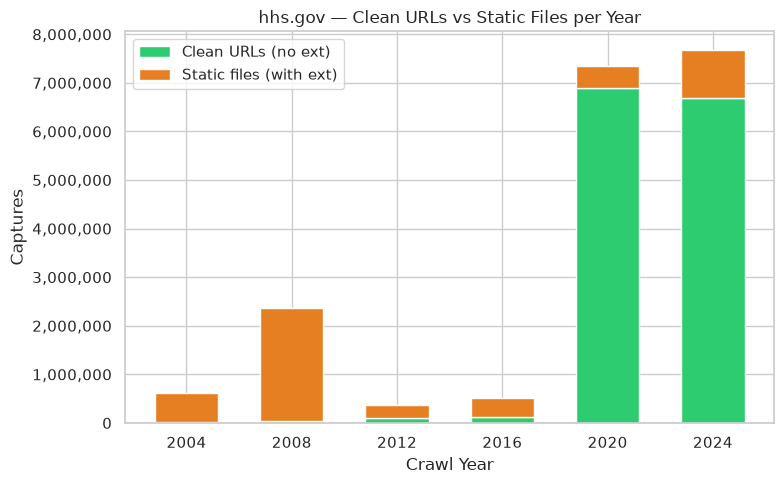

In [20]:
# Clean URLs (no extension) vs static files per year
clean_vs_static = hhs_con.sql("""
    SELECT
        crawl_year,
        SUM(CASE WHEN regexp_extract(regexp_extract(surtkey, '\\)([^?]*)', 1),
                '\\.([a-zA-Z0-9]+)$', 1) = '' THEN 1 ELSE 0 END) AS clean_urls,
        SUM(CASE WHEN regexp_extract(regexp_extract(surtkey, '\\)([^?]*)', 1),
                '\\.([a-zA-Z0-9]+)$', 1) != '' THEN 1 ELSE 0 END) AS static_files,
        COUNT(*) AS total
    FROM eot_captures
    GROUP BY 1 ORDER BY 1
""").df()
clean_vs_static['clean_pct'] = (clean_vs_static['clean_urls'] / clean_vs_static['total'] * 100).round(1)
print("Clean URLs vs static files:")
print(clean_vs_static.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(clean_vs_static))
ax.bar(x, clean_vs_static['clean_urls'], 0.6, label='Clean URLs (no ext)', color='#2ecc71')
ax.bar(x, clean_vs_static['static_files'], 0.6, bottom=clean_vs_static['clean_urls'],
       label='Static files (with ext)', color='#e67e22')
ax.set_xticks(x)
ax.set_xticklabels(clean_vs_static['crawl_year'])
ax.set_ylabel('Captures')
ax.set_xlabel('Crawl Year')
ax.set_title('hhs.gov — Clean URLs vs Static Files per Year')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
plt.tight_layout()
plt.show()

In [21]:
# Top PDF filenames
pdf_files = hhs_con.sql("""
    SELECT
        regexp_extract(regexp_extract(surtkey, '\\)([^?]*)', 1), '/([^/]+\\.pdf)$', 1) AS pdf_name,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    WHERE lower(regexp_extract(regexp_extract(surtkey, '\\)([^?]*)', 1),
                '\\.([a-zA-Z0-9]+)$', 1)) = 'pdf'
    GROUP BY 1, 2
""").df()

pdf_pivot = pdf_files.pivot_table(index='pdf_name', columns='crawl_year', values='n',
                                   aggfunc='sum').fillna(0).astype(int)
pdf_pivot['total'] = pdf_pivot.sum(axis=1)
pdf_pivot = pdf_pivot.sort_values('total', ascending=False)
print(f"Total unique PDF filenames: {len(pdf_pivot):,}")
pdf_pivot.head(30)

Total unique PDF filenames: 148,948


crawl_year,2004,2008,2012,2016,2020,2024,total
pdf_name,,,,,,,
report.pdf,138,713,330,1091,531,324,3127
rb.pdf,0,135,90,293,205,159,882
ib.pdf,0,53,55,206,111,149,574
index.pdf,26,26,49,243,94,95,533
execsum.pdf,28,208,69,76,49,17,447
42_cfr_parts_50_and_93_2005.pdf,0,1,3,276,8,22,310
,3,245,2,8,0,3,261
agenda.pdf,15,114,14,16,11,26,196
apa.pdf,24,46,24,48,29,8,179


In [22]:
# Drupal node IDs (if present)
node_stats = hhs_con.sql("""
    SELECT
        crawl_year,
        COUNT(*) AS node_urls,
        MIN(TRY_CAST(surtpath_2 AS INTEGER)) AS min_node_id,
        MAX(TRY_CAST(surtpath_2 AS INTEGER)) AS max_node_id,
        COUNT(DISTINCT surtpath_2) AS unique_nodes
    FROM eot_captures
    WHERE surtpath_1 = 'node'
    GROUP BY 1 ORDER BY 1
""").df()
if len(node_stats) > 0:
    print("Drupal /node/ statistics per crawl year:")
    print(node_stats.to_string(index=False))
else:
    print("No /node/ paths found — domain may not use Drupal.")

Drupal /node/ statistics per crawl year:
crawl_year  node_urls  min_node_id  max_node_id  unique_nodes
      2012       1127            1        15805           670
      2016       8581            1       255531          5504
      2020      49710            1       265266         28527
      2024       9899            1       304016          3365


In [23]:
hhs_con.close()